---
title: "Chapter 11, Simple DNN Autoencoder"
subtitle: "Modern Computer Vision by Kishore Ayyadevara and Yeshwanth Reddy (Packt)"
date: "June 2026"
date-format: "MMMM YYYY"
author: 
  - Notes by F.San Segundo
execute:
  echo: true
code-overflow: wrap
format: 
  html: 
    toc: true
    code-tools: true
    code-fold: show
    code-summary: "Hide the code"
    embed-resources: true
---

<a href="https://colab.research.google.com/github/sizhky/Modern-Computer-Vision-with-PyTorch/blob/master/Chapter11/simple_auto_encoder_with_different_latent_size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 135.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.3 MB/s eta 0:

In [2]:
print(f'Using device: {device}')

Using device: cuda


In [3]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

In [4]:
trn_ds = MNIST('/content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('/content/', transform=img_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.62MB/s]


In [5]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [6]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latend_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(True),
            nn.Linear(128, 64), nn.ReLU(True), 
            #nn.Linear(64, 12),  nn.ReLU(True), 
            nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential(
            #nn.Linear(latent_dim, 12), nn.ReLU(True),
            nn.Linear(latent_dim, 64), nn.ReLU(True),
            nn.Linear(64, 128), nn.ReLU(True), 
            nn.Linear(128, 28 * 28), nn.Tanh())

    def forward(self, x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x

In [7]:
%pip install torch_summary
from torchsummary import summary
model = AutoEncoder(3).to(device)
summary(model, torch.zeros(2,1,28,28));

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 3]                   --
|    └─Linear: 2-1                       [-1, 128]                 100,480
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 64]                  8,256
|    └─ReLU: 2-4                         [-1, 64]                  --
|    └─Linear: 2-5                       [-1, 3]                   195
├─Sequential: 1-2                        [-1, 784]                 --
|    └─Linear: 2-6                       [-1, 64]                  256
|    └─ReLU: 2-7                         [-1, 64]                  --
|    └─Linear: 2-8                       [-1, 128]                 8,320
|    └─ReLU: 2-9                         [-1, 128]                 --
|    └─Linear: 2-10                      [-1, 784]                 101,136
|    └─Tanh: 2-11                        [-1, 784]                 

In [8]:
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  trn_loss: 0.255  val_loss: 0.192  (18.93s - 75.74s remaining)
EPOCH: 2.000  trn_loss: 0.177  val_loss: 0.165  (37.99s - 56.99s remaining)
EPOCH: 3.000  trn_loss: 0.160  val_loss: 0.155  (57.39s - 38.26s remaining)
EPOCH: 4.000  trn_loss: 0.153  val_loss: 0.150  (76.58s - 19.14s remaining)
EPOCH: 5.000  trn_loss: 0.149  val_loss: 0.147  (95.65s - 0.00s remaining)


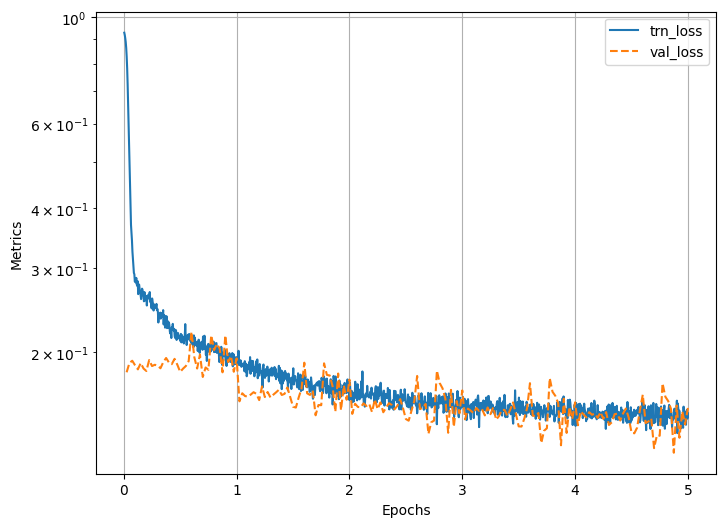

In [11]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch+1)
log.plot(log=True)

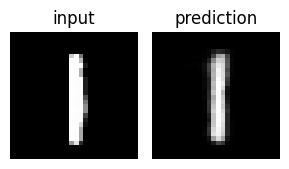

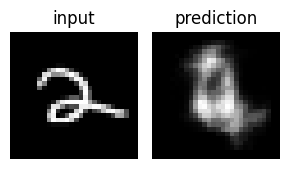

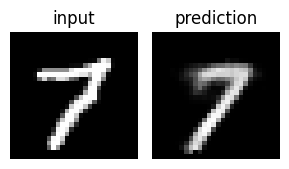

In [13]:
import matplotlib.pyplot as plt
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1,2,figsize=(3,3)) 
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

EPOCH: 1.000  trn_loss: 0.246  val_loss: 0.141  (18.87s - 75.50s remaining)
EPOCH: 2.000  trn_loss: 0.117  val_loss: 0.102  (37.77s - 56.66s remaining)
EPOCH: 3.000  trn_loss: 0.092  val_loss: 0.082  (56.62s - 37.75s remaining)
EPOCH: 4.000  trn_loss: 0.078  val_loss: 0.072  (75.61s - 18.90s remaining)
EPOCH: 5.000  trn_loss: 0.071  val_loss: 0.067  (94.66s - 0.00s remaining)


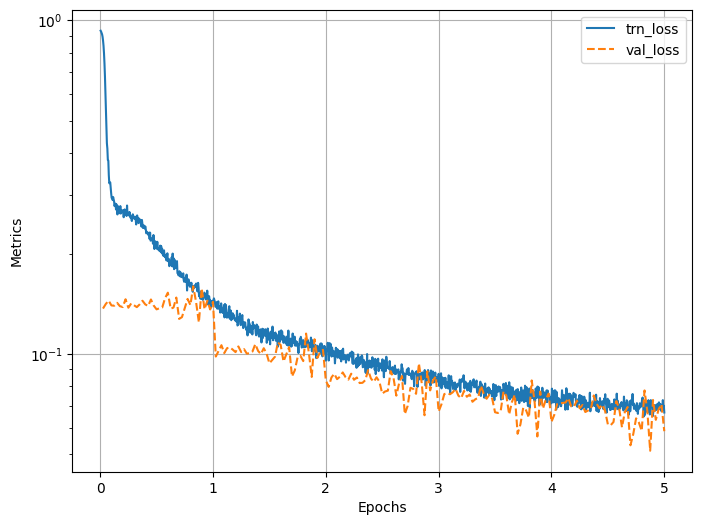

EPOCH: 1.000  trn_loss: 0.268  val_loss: 0.216  (19.07s - 76.27s remaining)
EPOCH: 2.000  trn_loss: 0.210  val_loss: 0.203  (38.26s - 57.38s remaining)
EPOCH: 3.000  trn_loss: 0.196  val_loss: 0.189  (57.39s - 38.26s remaining)
EPOCH: 4.000  trn_loss: 0.185  val_loss: 0.182  (76.54s - 19.14s remaining)
EPOCH: 5.000  trn_loss: 0.180  val_loss: 0.178  (95.69s - 0.00s remaining)


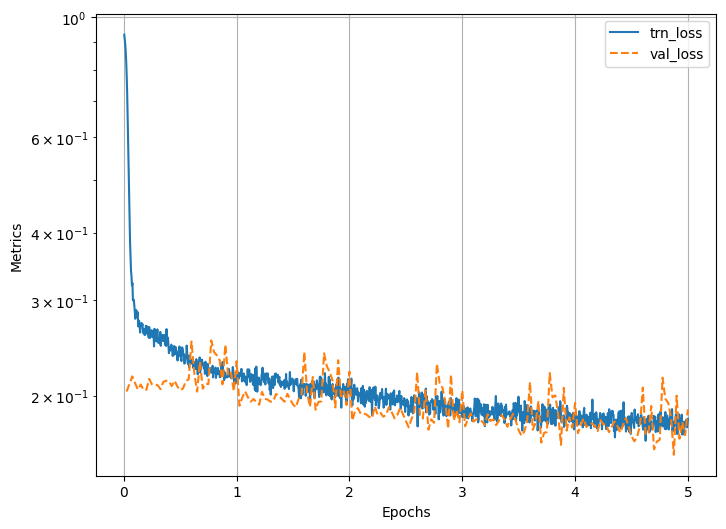

EPOCH: 1.000  trn_loss: 0.258  val_loss: 0.197  (18.90s - 75.60s remaining)
EPOCH: 2.000  trn_loss: 0.185  val_loss: 0.172  (37.90s - 56.85s remaining)
EPOCH: 3.000  trn_loss: 0.165  val_loss: 0.159  (57.01s - 38.00s remaining)
EPOCH: 4.000  trn_loss: 0.156  val_loss: 0.153  (76.15s - 19.04s remaining)
EPOCH: 5.000  trn_loss: 0.151  val_loss: 0.148  (95.17s - 0.00s remaining)


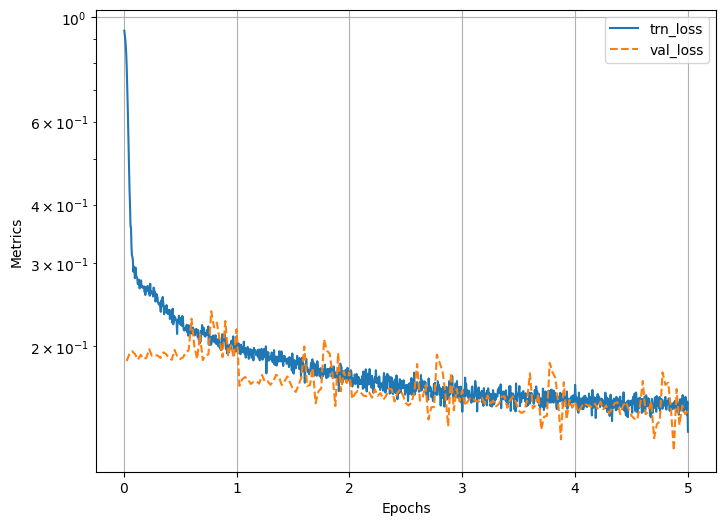

EPOCH: 1.000  trn_loss: 0.246  val_loss: 0.160  (19.10s - 76.38s remaining)
EPOCH: 2.000  trn_loss: 0.146  val_loss: 0.137  (38.13s - 57.20s remaining)
EPOCH: 3.000  trn_loss: 0.132  val_loss: 0.127  (57.07s - 38.05s remaining)
EPOCH: 4.000  trn_loss: 0.125  val_loss: 0.122  (76.03s - 19.01s remaining)
EPOCH: 5.000  trn_loss: 0.120  val_loss: 0.119  (95.22s - 0.00s remaining)


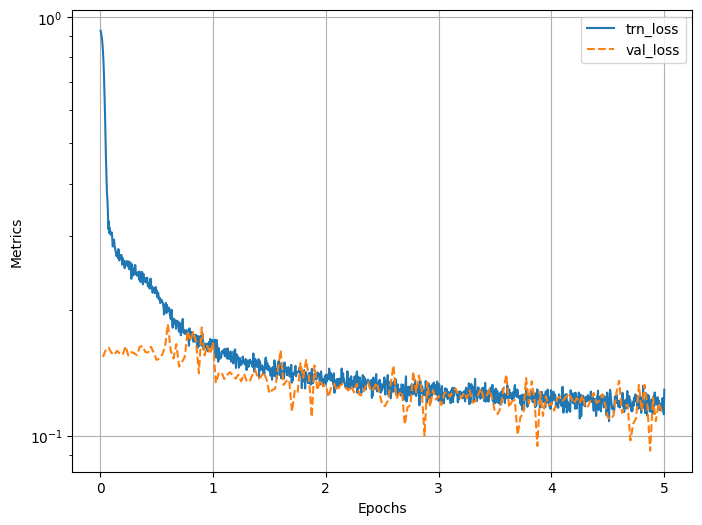

EPOCH: 1.000  trn_loss: 0.247  val_loss: 0.151  (19.05s - 76.19s remaining)
EPOCH: 2.000  trn_loss: 0.129  val_loss: 0.115  (38.11s - 57.16s remaining)
EPOCH: 3.000  trn_loss: 0.108  val_loss: 0.100  (57.28s - 38.19s remaining)
EPOCH: 4.000  trn_loss: 0.098  val_loss: 0.094  (76.35s - 19.09s remaining)
EPOCH: 5.000  trn_loss: 0.093  val_loss: 0.088  (95.69s - 0.00s remaining)


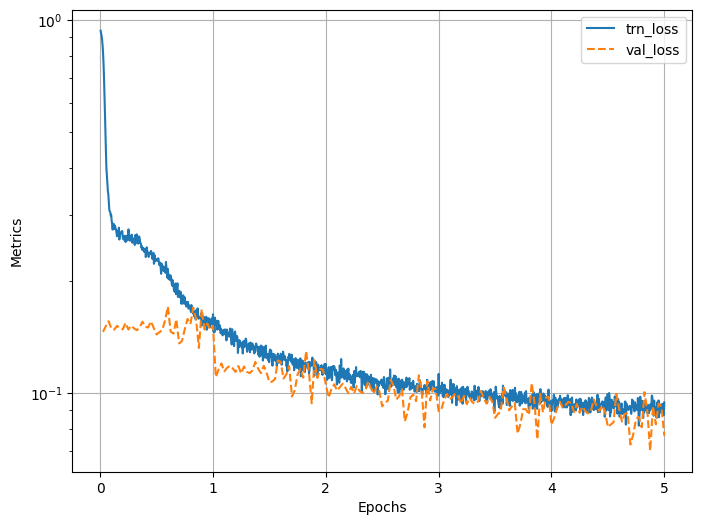

In [14]:
def train_aec(latent_dim):
    model = AutoEncoder(latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

    num_epochs = 5
    log = Report(num_epochs)

    for epoch in range(num_epochs):
        N = len(trn_dl)
        for ix, (data, _) in enumerate(trn_dl):
            loss = train_batch(data, model, criterion, optimizer)
            log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

        N = len(val_dl)
        for ix, (data, _) in enumerate(val_dl):
            loss = validate_batch(data, model, criterion)
            log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
        log.report_avgs(epoch+1)
    log.plot(log=True)
    return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

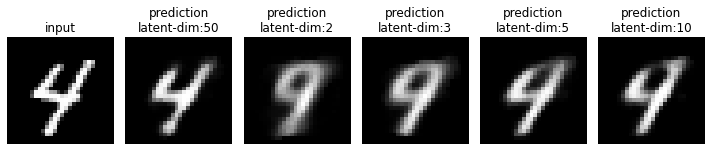

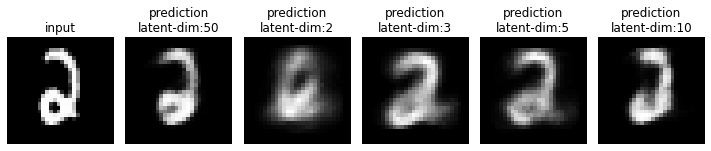

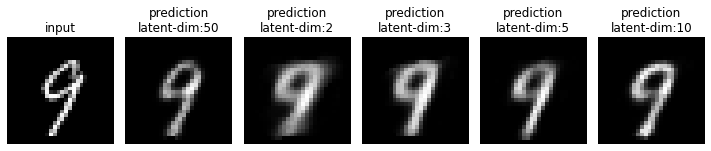

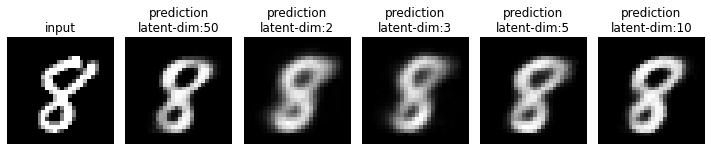

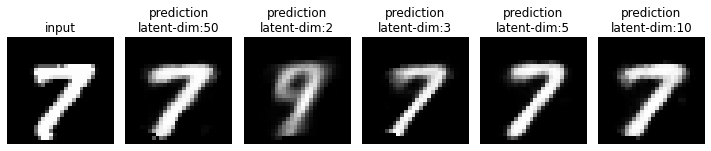

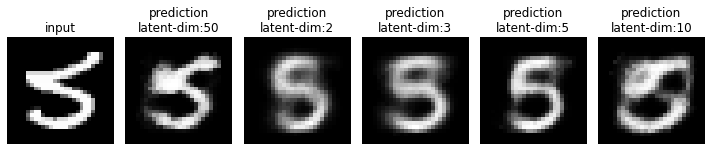

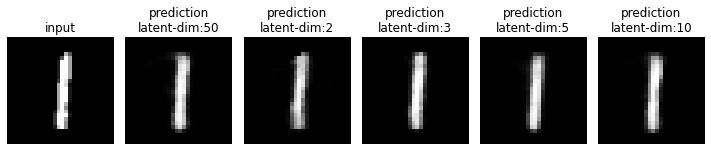

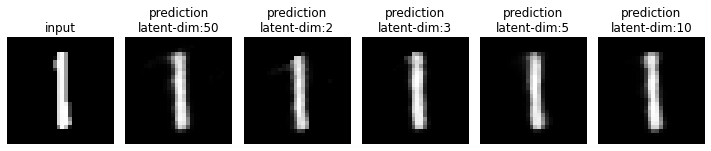

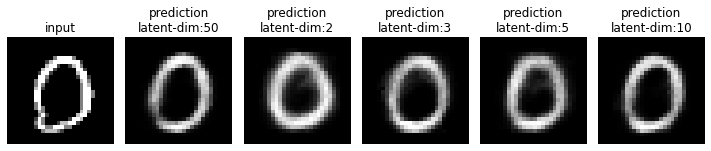

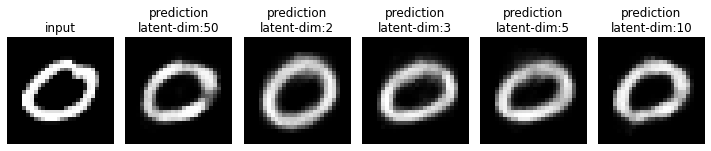

In [ ]:
for _ in range(10):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
    ax = iter(ax.flat)
    show(im[0], ax=next(ax), title='input')
    for model in aecs:
        _im = model(im[None])[0]
        show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim:{model.latend_dim}')
    plt.tight_layout()
    plt.show()